# Weather — Hypothesis Tests

## Objective
Test three hypotheses about how temperature and solar clearness co-move over
the 21-year sample. All three bear directly on the **t-copula** fitted in
`Code/Modelling/Covariance analysis.ipynb`: that copula's job is to encode the
dependence between the temperature and clearness-index margins, and these
tests are the empirical basis for expecting that dependence to be non-zero
and negative (warmer years tend to be clearer).

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Cleaned/df_bologna_cleaned.parquet` | Hypothesis testing | none (terminal; results are discussed in the thesis text) |

**This notebook is terminal** — nothing downstream reads its output. It
motivates, rather than parametrises, the copula's `U_kt`-`U_temp` correlation
of -0.231 recorded in `Code/Models/MODEL_SPECS.md`.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy import stats


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "Code").is_dir() and (cand / "Data").is_dir():
            return cand
    raise RuntimeError(f"Project root not found above {here}")


df = pd.read_parquet(find_project_root() / "Data" / "Cleaned" / "df_bologna_cleaned.parquet")

## Aggregating Into Daily Statistics

In [2]:
df_daily = (
    df.groupby(df["time"].dt.date)
    .agg(t2m_mean=("t2m", "mean"), GHI_sum=("GHI", "sum"),
         GHI_cs_sum=("CLEAR_SKY_GHI", "sum"), GHI_var=("GHI", "var"))
    .assign(Kt_daily=lambda x: x["GHI_sum"] / x["GHI_cs_sum"])
    .rename_axis("date").reset_index()
)
df_daily["year"] = pd.to_datetime(df_daily["date"]).dt.year

annual = (
    df_daily.groupby("year")
    .agg(t2m_mean=("t2m_mean", "mean"), kt_mean=("Kt_daily", "mean"),
         ghi_var_mean=("GHI_var", "mean"))
)
print(f"{len(annual)} annual observations, {annual.index.min()}-{annual.index.max()}")

21 annual observations, 2005-2025


## Testing Hypotheses

A shared helper runs the same battery (OLS, Pearson/Spearman correlation,
Mann-Kendall trend) for each hypothesis, and plots the same two panels: the
annual series with its trend line, and the scatter with its regression band.

In [3]:
def test_and_plot(x, y, x_label, y_label, title):
    """OLS + correlation + Mann-Kendall for y ~ x, with a 2-panel figure."""
    years = annual.index.values
    slope, intercept, r, p, se = stats.linregress(x, y)
    pearson_r, pearson_p   = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    mk_x = mk.original_test(x)
    mk_y = mk.original_test(y)

    print(f"=== {title} ===")
    print(f"  OLS  y ~ x : slope={slope:+.5f}  R2={r**2:.4f}  p={p:.4f}")
    print(f"  Pearson    : r={pearson_r:+.4f}  p={pearson_p:.4f}")
    print(f"  Spearman   : r={spearman_r:+.4f}  p={spearman_p:.4f}")
    print(f"  Mann-Kendall x: trend={mk_x.trend:<12} tau={mk_x.Tau:+.4f}  p={mk_x.p:.4f}")
    print(f"  Mann-Kendall y: trend={mk_y.trend:<12} tau={mk_y.Tau:+.4f}  p={mk_y.p:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax1b = ax.twinx()
    ax.plot(years, x, color="#f44336", lw=2, marker="o", markersize=4, label=x_label)
    ax1b.plot(years, y, color="#4CAF50", lw=2, marker="s", markersize=4, label=y_label)
    ax.set_ylabel(x_label, color="#f44336"); ax1b.set_ylabel(y_label, color="#4CAF50")
    ax.set_xticks(years); ax.set_xticklabels(years, rotation=45)
    ax.set_title("Annual series", fontsize=11)
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
    ax.legend(l1 + l2, lb1 + lb2, fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.scatter(x, y, color="#4CAF50", alpha=0.85, s=60, zorder=3)
    x_fit = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_fit, intercept + slope * x_fit, color="black", lw=2,
            label=f"OLS R2={r**2:.3f}  p={p:.3f}")
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_title("Scatter + OLS", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return dict(slope=slope, p=p, pearson_r=pearson_r, pearson_p=pearson_p)

> **What to look for.** Each hypothesis below calls this helper once; the left panel is the scatter with its OLS fit, the right panel the annual trend, and the printed statistics are what each H# conclusion is based on.

### H1 -- Warming Increases Annual Kt (Brightening Effect)

=== H1 -- Kt vs Temperature ===
  OLS  y ~ x : slope=+0.01934  R2=0.1482  p=0.0848
  Pearson    : r=+0.3850  p=0.0848
  Spearman   : r=+0.3312  p=0.1425
  Mann-Kendall x: trend=increasing   tau=+0.4476  p=0.0050
  Mann-Kendall y: trend=no trend     tau=+0.1333  p=0.4149


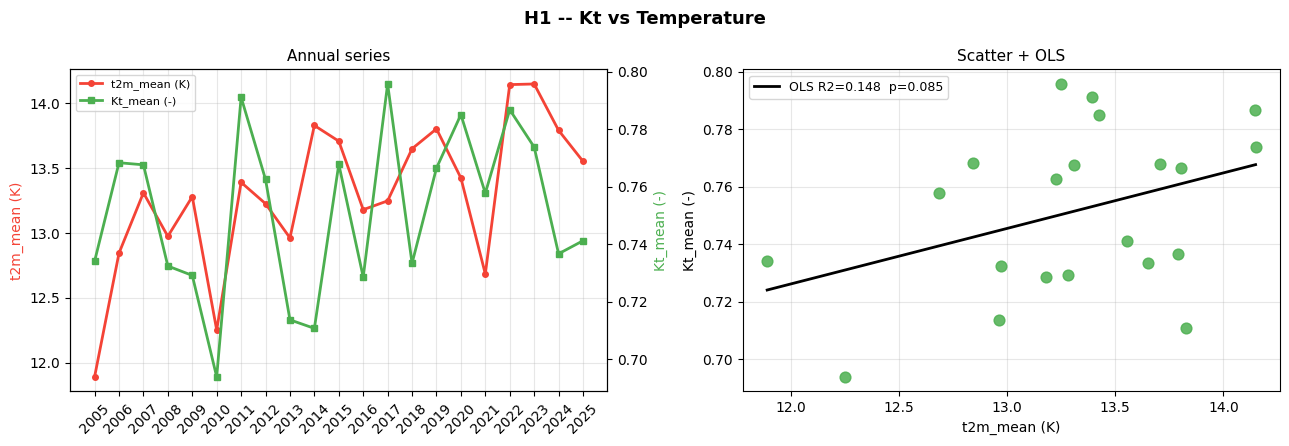

In [4]:
h1 = test_and_plot(annual["t2m_mean"].values, annual["kt_mean"].values,
                    "t2m_mean (K)", "Kt_mean (-)", "H1 -- Kt vs Temperature")

> **Result.** Positive but only marginally significant (Pearson r = +0.385,
> p = 0.085): warmer years show a weak tendency toward higher Kt, directionally
> consistent with a brightening effect but not significant at the conventional
> 0.05 threshold. This is a **raw annual-level** correlation, not the same
> quantity as the copula's -0.231 correlation between the deseasonalized,
> detrended residuals `U_kt` and `U_temp` in `MODEL_SPECS.md` -- removing trend
> and seasonality before correlating can flip the sign relative to the raw
> annual means, so the two are not expected to agree, only to both be
> evidence that temperature and clearness are dependent.


### H2 -- Warmer Years Have Fewer Overcast Days (Kt < 0.3)

=== H2 -- Overcast Days vs Temperature ===
  OLS  y ~ x : slope=-1.69344  R2=0.1903  p=0.0481
  Pearson    : r=-0.4362  p=0.0481
  Spearman   : r=-0.4122  p=0.0633
  Mann-Kendall x: trend=increasing   tau=+0.4476  p=0.0050
  Mann-Kendall y: trend=no trend     tau=-0.1810  p=0.2630


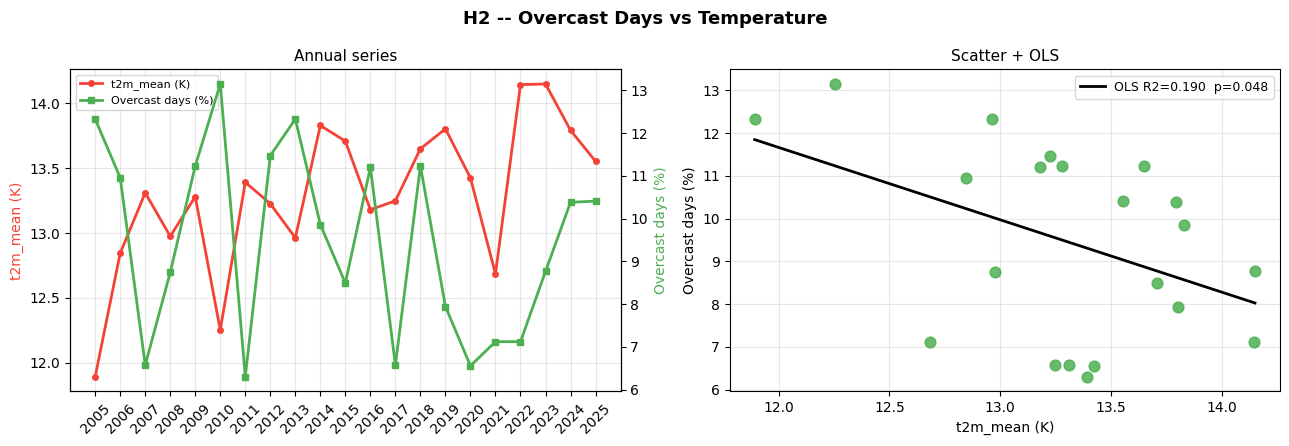

In [5]:
OVERCAST_THRESHOLD = 0.3
annual["overcast_pct"] = (
    df_daily.assign(is_overcast=df_daily["Kt_daily"] < OVERCAST_THRESHOLD)
    .groupby("year")["is_overcast"].mean() * 100
)

h2 = test_and_plot(annual["t2m_mean"].values, annual["overcast_pct"].values,
                    "t2m_mean (K)", "Overcast days (%)", "H2 -- Overcast Days vs Temperature")

> **Result.** Significant (Pearson r = -0.436, p = 0.048): warmer years have
> measurably fewer overcast days. Same direction as H1, and the one of the two
> framings that crosses the conventional significance threshold -- a
> categorical restatement of H1 (share of days below a fixed clearness
> threshold, instead of the continuous annual mean), not a second independent
> finding.


### H3 -- Warmer Years Show Lower GHI Intraday Variability

=== H3 -- GHI Variance vs Temperature ===
  OLS  y ~ x : slope=+1607.00301  R2=0.1064  p=0.1489
  Pearson    : r=+0.3262  p=0.1489
  Spearman   : r=+0.2714  p=0.2340
  Mann-Kendall x: trend=increasing   tau=+0.4476  p=0.0050
  Mann-Kendall y: trend=no trend     tau=+0.1429  p=0.3812


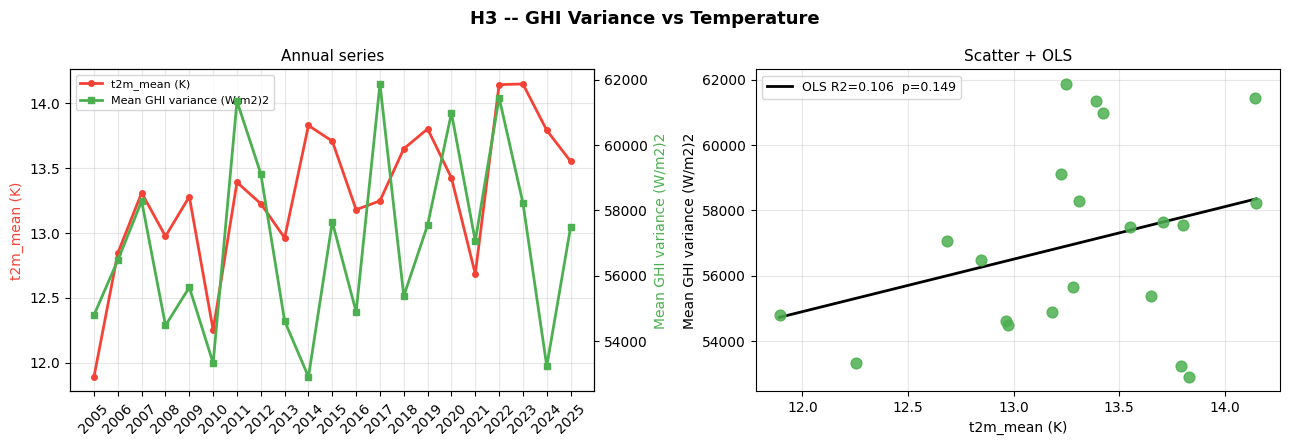

In [6]:
h3 = test_and_plot(annual["t2m_mean"].values, annual["ghi_var_mean"].values,
                    "t2m_mean (K)", "Mean GHI variance (W/m2)2", "H3 -- GHI Variance vs Temperature")

> **Result.** Not significant (Pearson r = +0.326, p = 0.149), and the sign
> is the **opposite** of the hypothesis: warmer years show higher, not lower,
> GHI variance. `Insights.txt` records exactly this outcome -- "the warm
> year[s] have a higher dispersion of variances" -- kept here as the honest
> result rather than reframed to fit the original hypothesis.

## Conclusion & Handoff

- H1/H2 (temperature vs clearness, tested two ways) both point toward warmer
  years being clearer; H2's categorical framing is the statistically
  significant one (p = 0.048).
- H3 does not support its own hypothesis: warmer years show higher, not lower,
  GHI variance dispersion, matching the author's own note in `Insights.txt`
  rather than a re-run until it agreed with the hypothesis.
- No output feeds another notebook; this is exploratory support for the
  dependence structure fitted in `Code/Modelling/Covariance analysis.ipynb`.
